<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Fine_Tune_a_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

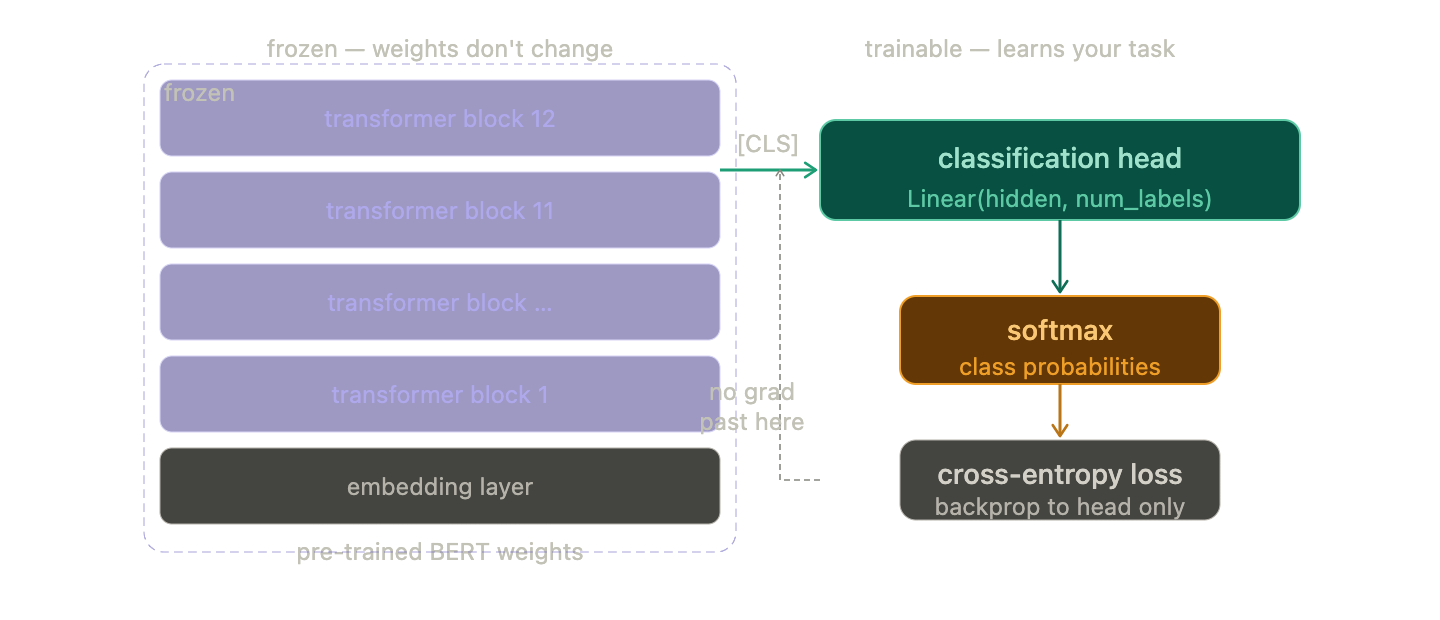

The gradient flows back through the loss, through the head, and stops — it does not update the frozen BERT layers. That's the entire fine-tuning trick: BERT already knows language, your head learns your task.

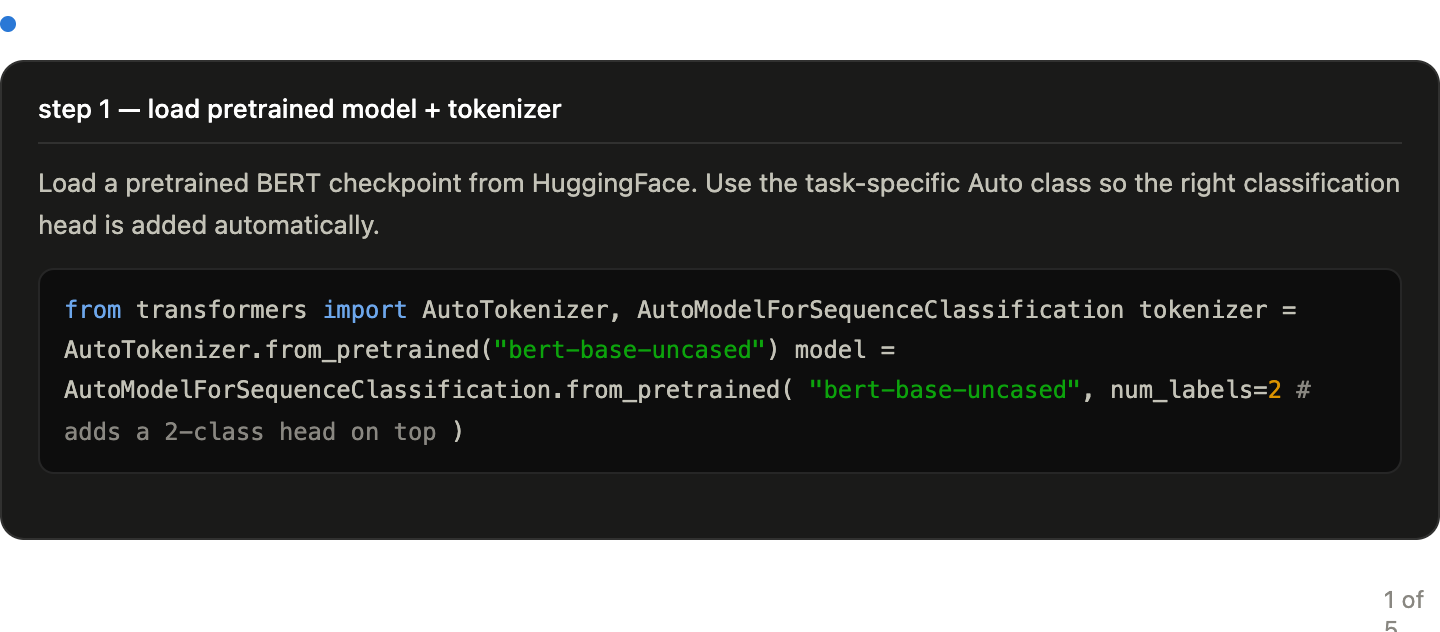

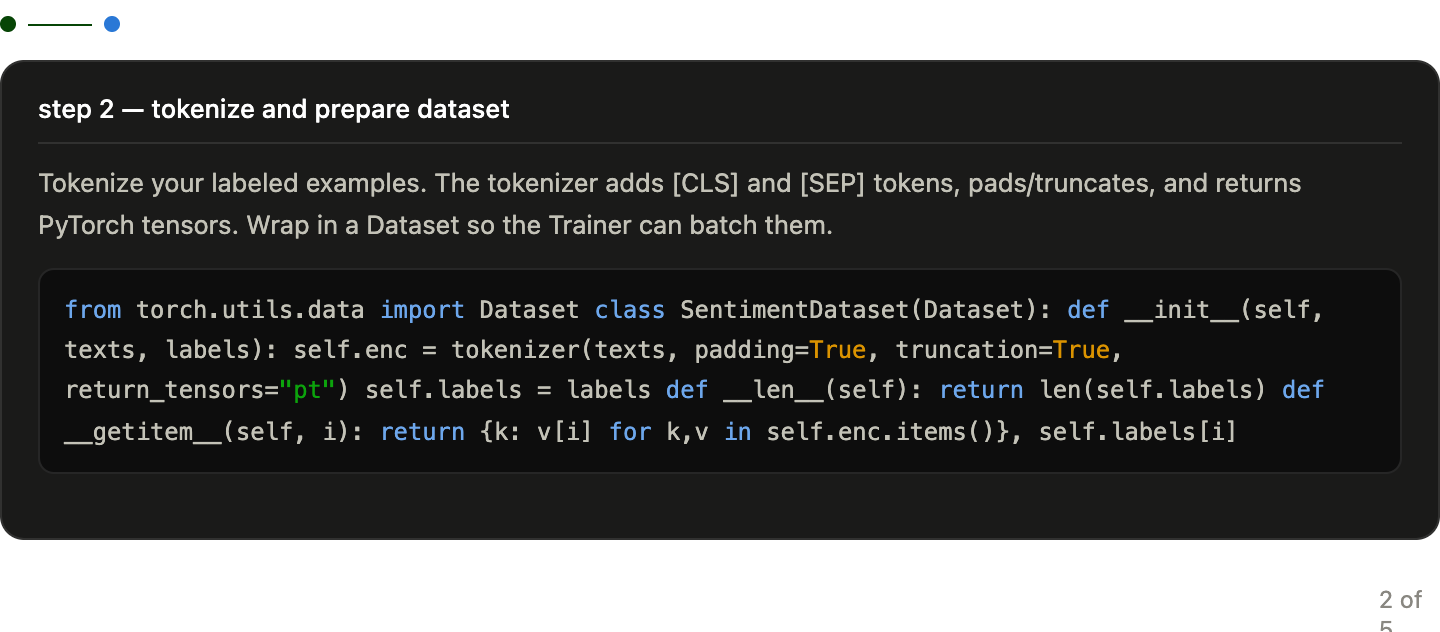

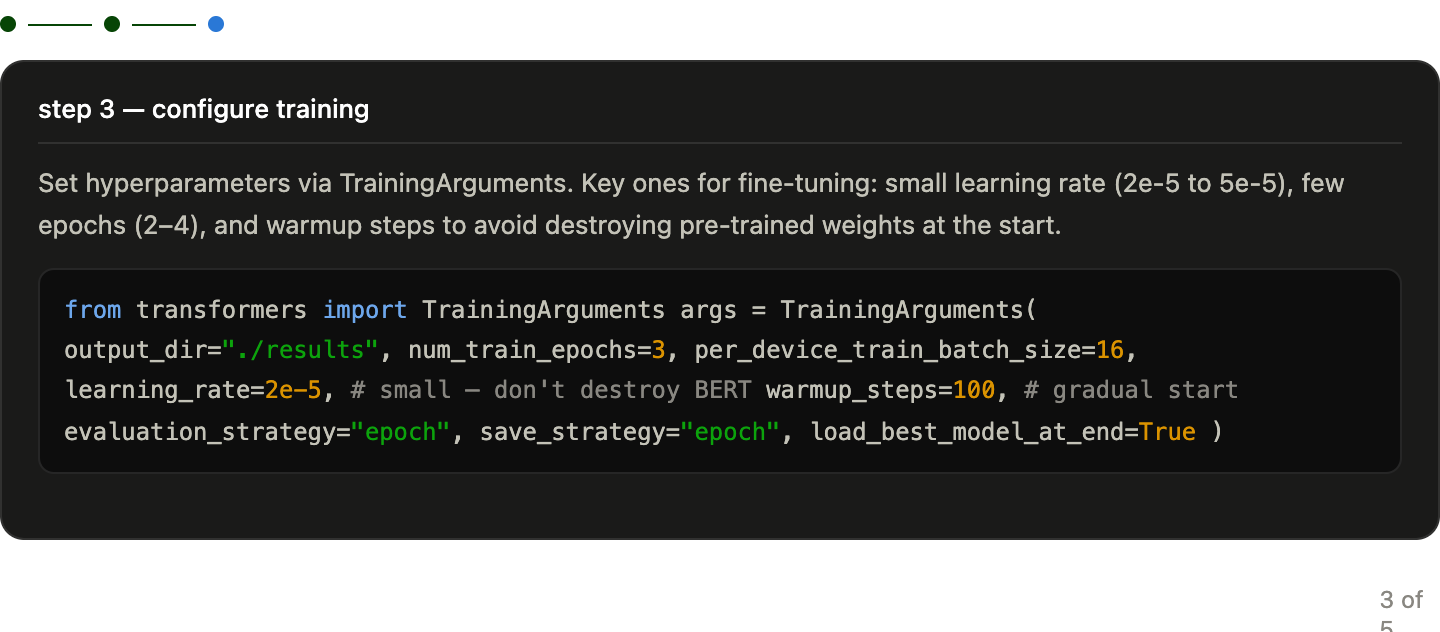

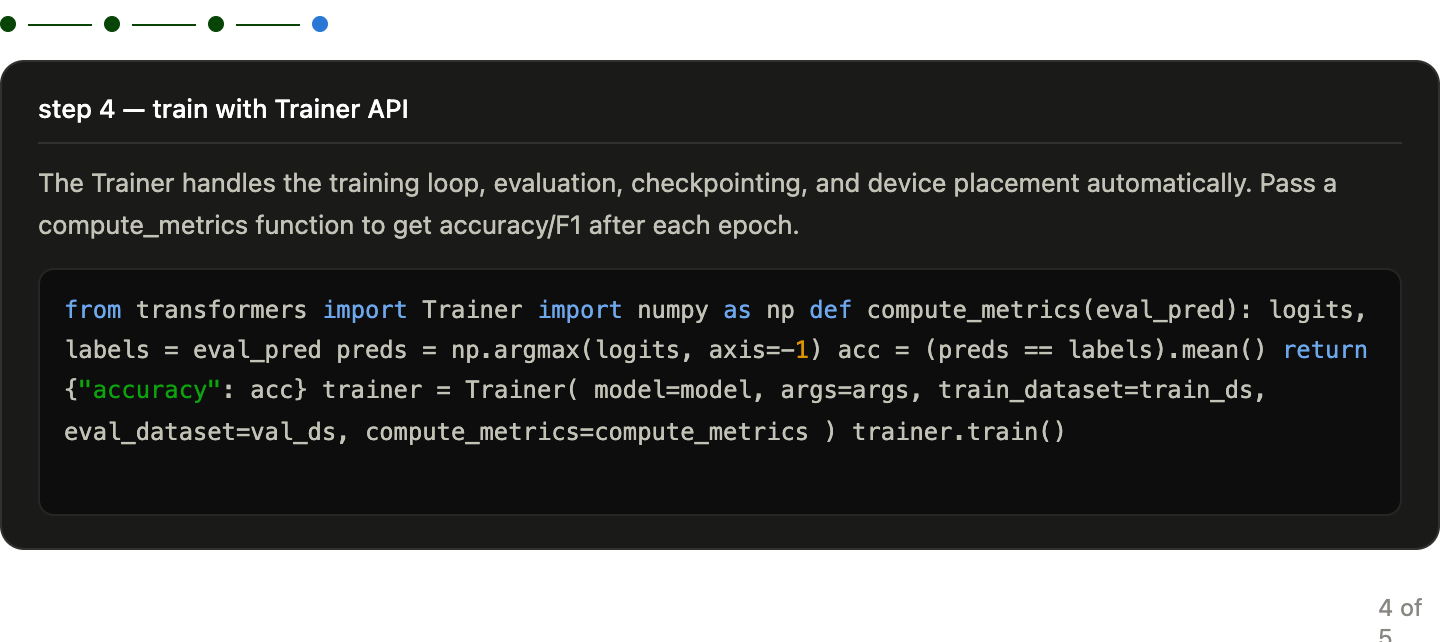

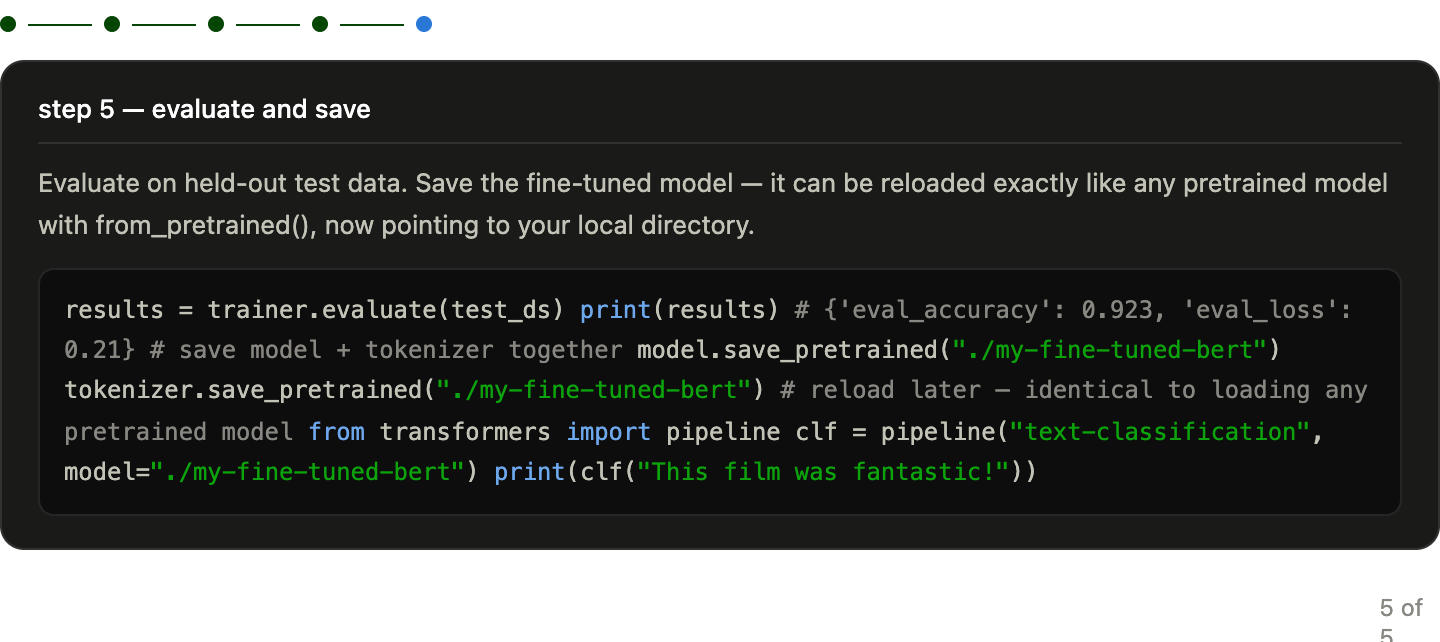

## **Key concepts**
Fine-tuning means taking a model already trained on a massive corpus (BERT, GPT, etc.) and continuing training on your own small labeled dataset for a specific task. The pre-trained model has already learned the language — fine-tuning teaches it your task.

Transfer learning is the principle behind it: knowledge learned in one context transfers to another. BERT learned grammar, semantics, and world knowledge from Wikipedia and Books. Your sentiment dataset teaches it "in this domain, these patterns mean positive/negative."

The classification head is the only new thing added. For BERT sequence classification, it's a single Linear(hidden_size, num_labels) layer on top of the [CLS] token output. BERT's 12 transformer layers stay intact — only this tiny head is randomly initialized.

Frozen vs unfrozen layers — you have three strategies:

Freeze all BERT layers, only train the head. Fastest, least data needed, but lowest accuracy.
Freeze lower layers, unfreeze upper layers + head. Middle ground.
Unfreeze everything (full fine-tuning). Highest accuracy but needs more data and careful learning rate to avoid destroying pre-trained knowledge.

Learning rate scheduling with warmup: start with a near-zero learning rate and ramp it up over the first N steps. This prevents the randomly initialized head from sending huge gradients through BERT and destroying pre-trained weights in the first few batches.

## **Common MCQ traps**
Trap 1 — fine-tuning changes the model's architecture. No. The architecture stays identical. Only the weights change (and a classification head is added on top). Exams love wording this as "fine-tuning modifies the transformer layers" — false, it only modifies their weights (or not, if frozen).

Trap 2 — you need a lot of data for fine-tuning. One of the main advantages of fine-tuning over training from scratch is that it works well with very little data — even a few hundred labeled examples can produce a good model. This is because BERT already knows language.

Trap 3 — you should use the same learning rate as pre-training. No. BERT was pre-trained at a higher learning rate over billions of tokens. Fine-tuning uses a much smaller learning rate (1e-5 to 5e-5) over just a few epochs — otherwise you get catastrophic forgetting.